In [1]:
import sys

sys.path.append("C:/Users/siddh/Desktop/Graduate files/Research/mpemba_functions/")
import mpemba
import fokker_planck

# You may also need to download the tqdm and xarray libraries from pip.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy

plt.style.use('default')

In [2]:
D = 1930.3194221999997 # Inferred from harmonic well data and rescaled to be in units of sigma^2/s. See params.txt
k_BT = 1 # Scale energies to be in units of k_BT
gamma = k_BT/D

directory = "./"
filename = "data4"
states=[0.0,1.0]
filenames = [directory+filename+f"_converted_p={state}.csv" for state in states]
data = mpemba.file_processing.load_processed_data(filenames, temperatures=states) # I used the word 'temperatures' and 'T' when writing my simulations, but for the most part it's just an index variable and so you can pass 'states' to it instead. One slight caveat is that one of the states must always be equal to 1. But apart from that it doesn't really matter.

potential = mpemba.special_potentials.SimpleHarmonic(k=1, x_min=-5, x_max=5) # k = 1 in our scaled units

ensemble = mpemba.Ensemble(data, potential) # the Ensemble object contains a bunch of handy methods to histogram data, calculate a bunch of useful things, and so on

100%|██████████| 2/2 [00:03<00:00,  1.75s/it]


In [3]:
ensemble.data # An xarray.DataArray object, basically a 3-dimensional spreadsheet, with coordinate labels (T, n, t) for state, ensemble index, and time

<xarray.DataArray (T: 2, n: 1323, t: 6000)>
array([[[ 0.24845335,  0.5762598 ,  0.47205232, ...,  0.6092228 ,
          0.72039617,  0.64305714],
        [ 0.92763981,  0.92314031,  0.52018983, ..., -0.14189376,
         -0.46730999, -0.27505516],
        [ 0.92827784,  0.57139367,  0.29695749, ...,  1.7996239 ,
          1.34322222,  1.28669516],
        ...,
        [ 1.62169129,  1.67107151,  2.00562483, ...,  0.90894189,
          0.52714144,  0.68476203],
        [ 0.78836005,  0.75421146,  1.14758681, ...,  0.51984225,
          0.11777739,  0.32641612],
        [-0.68635709, -0.3402384 , -0.20690083, ...,  2.16155512,
          2.45464638,  2.30067777]],

       [[-4.15665255, -4.36206307, -4.1789834 , ..., -1.06113451,
         -0.78888856, -0.84031618],
        [-3.91871708, -3.81819015, -4.11438582, ...,  0.03912899,
          0.02661609, -0.33160126],
        [-4.19407696, -4.20343307, -4.0709335 , ..., -1.75016273,
         -1.62569084, -1.59623221],
        ...,
        [ 3.53219335,  3.00936095,  3.29494827, ..., -0.34117639,
         -0.02264034, -0.13135208],
        [-4.20167612, -4.33519938, -4.13931638, ..., -1.44332062,
         -0.85107689, -0.70331235],
        [-3.99733691, -3.98509066, -3.96349305, ...,  0.10014602,
          0.18065136,  0.11680131]]])
Coordinates:
  * T        (T) float64 1.0 0.0
  * t        (t) float64 0.0 1e-05 2e-05 3e-05 ... 0.05997 0.05998 0.05999
Dimensions without coordinates: n

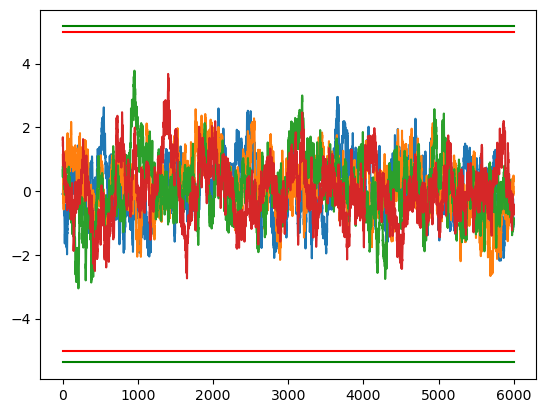

In [4]:
ensemble.plot_sample_trajectories() # The green lines are the hard boundaries encoded by the mesh; the red lines are the global maximum and minimum respectively. Ideally we want the red lines to be inside the green lines.

Final histogram, T = 1.0: chi^2 = 0.49773337974426524
Final histogram, T = 0.0: chi^2 = 0.4415354718140281


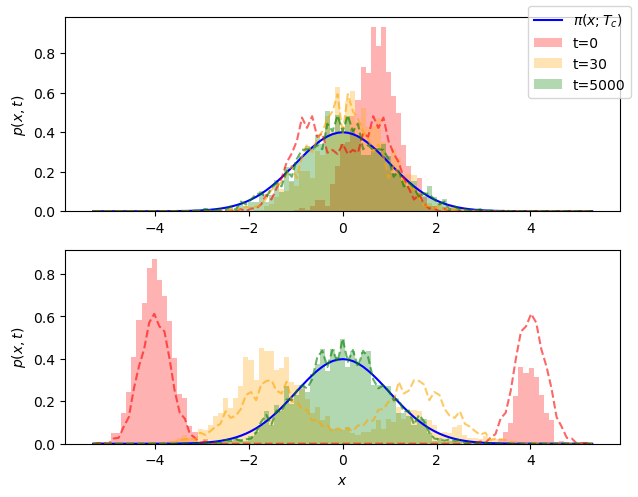

In [5]:
bins, heights = ensemble.get_histograms(regenerate=True, symmetric_domain=True) # We force the binning algorithm to use a symmetric domain; otherwise we get nonmonotonic behaviour because the symmetrised pdf is incorrectly calculated.
# get_histograms caches the histogram information, so it is essential that you run this line of code before you do anything else.
gutcheck_bins, gutcheck_heights = ensemble.gut_checks(mid=30, end=5000, plot_init=False, plot_symmetrised_histograms=True) # Plot some histograms just so that we know everything's working
# Symmetrised histograms are dashed lines in the same colour as the histogram

# Legend labels are in multiples of dt

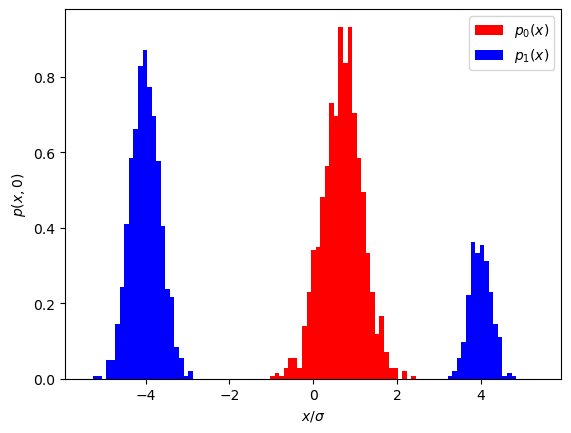

In [6]:
plt.bar(gutcheck_bins, gutcheck_heights[0][0,:], width=ensemble.dx, color='r', label=r'$p_0(x)$')
plt.bar(gutcheck_bins, gutcheck_heights[0][1,:], width=ensemble.dx, color='b', label=r'$p_1(x)$') # Plot PDFs
dx_bins = gutcheck_bins[1]-gutcheck_bins[0]
gaussian = lambda x, mu, sigma: np.exp(-(x-mu)**2/(2*sigma**2))
x = np.linspace(-5, 5, 1000)
dx = x[1]-x[0]
p_A = gaussian(x, 0.8, 0.2) + gaussian(x, 0.6, 0.2)
p_B = gaussian(x, 4, 0.2) + 0.5*gaussian(x, -4, 0.2)
# plt.plot(x, p_A/(p_A.sum()*dx), linestyle = '--', color='orange')

# plt.plot(x, p_B/(p_B.sum()*dx), linestyle='--', color='cyan')
plt.xlabel(r'$x/\sigma$')
plt.ylabel(r'$p(x,0)$')
plt.legend()

In [7]:
dx = gutcheck_bins[1]-gutcheck_bins[0]
heights_df = pd.DataFrame(np.array([*(gutcheck_heights[0]), gaussian(gutcheck_bins, 0, 1)/(gaussian(gutcheck_bins, 0, 1).sum()*dx)]).T, index=gutcheck_bins, columns=['p_0','p_1', 'pi'])
heights_df.index.name='x'
# heights_df.to_csv("symmetrisation_pdfs.csv")

In [8]:
gutcheck_bins[1]-gutcheck_bins[0]

0.10856918073593746

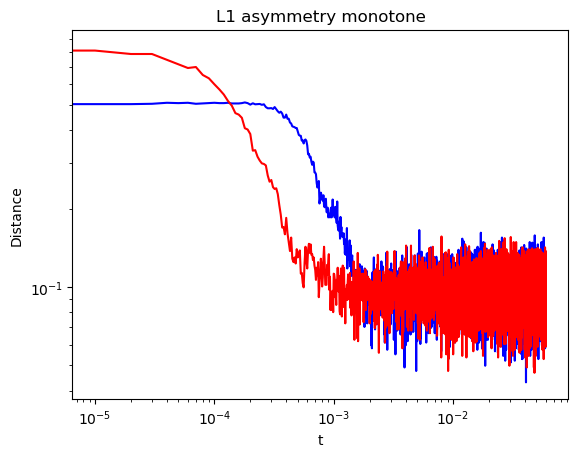

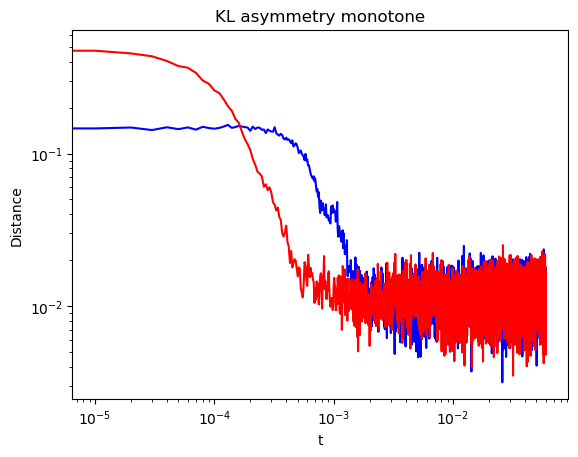

In [9]:
L1_asymmetry_monotone = mpemba.distance_functions.asymmetry_monotone_loader(mpemba.distance_functions.L1)
KL_asymmetry_monotone = mpemba.distance_functions.asymmetry_monotone_loader(mpemba.distance_functions.KL_constructor(epsilon=1e-8))
# asymmetry_monotone_loader takes in a distance function D (that obeys the properties from Lu and Raz) and returns an 'asymmetry distance', D_a[p] = D[p,G(p)] where G is the `twirling` operator you defined.
# The KL divergence is infinite if any bins have zero counts in them. To avoid this problem, I by default add a pseudocount in each zero-bin (by replacing every 0 with epsilon=1/(dx*N), which is hopefully very small). This is a bit unnatural, which is why we like the L1 distance better.

ensemble.plot_distances(title="L1 asymmetry monotone", distance_function=L1_asymmetry_monotone)
plt.show()
plt.close()
ensemble.plot_distances(title="KL asymmetry monotone", distance_function=KL_asymmetry_monotone)
plt.show()

0.21794922335726027 0.21794922335726027
0.21794922335726027 0.21794922335726027


(0.03, 2)

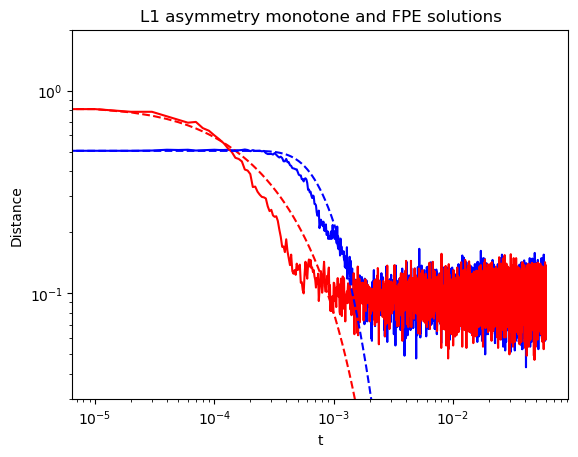

In [10]:
p_0 = np.copy(ensemble.heights[0,:,0]) # Don't mutate the heights array
p_1 = np.copy(ensemble.heights[1,:,0])
# Pick out the initial states

p_trajectories = np.array([fokker_planck.fokker_planck_solver(p_0, potential, D, t_max=ensemble.expt_length, x=ensemble.bins, error_tolerance=1e-1, saving_timestep=10, dt=1e-6) for p_0 in [p_0, p_1]])
# FPE calculations done using Grima-Newman method
L1_distances = L1_asymmetry_monotone(p_trajectories, None, dx=ensemble.dx, axis=1)
KL_distances = KL_asymmetry_monotone(p_trajectories, None, dx=ensemble.dx, axis=1) # Since the asymmetry metric of p is calculated wrt G(p), a second argument to the distance function is unnecessary, except for consistency with other code.

ensemble.plot_distances(distance_function=L1_asymmetry_monotone)
times = np.arange(0,p_trajectories.shape[2]*1e-5, 1e-5)
plt.loglog(times, L1_distances[0,:], '--', color='r')
plt.loglog(times, L1_distances[1,:], '--', color='b')
plt.title("L1 asymmetry monotone and FPE solutions")
plt.ylim((0.03, 2))

(0.05, 4.272877376749566)

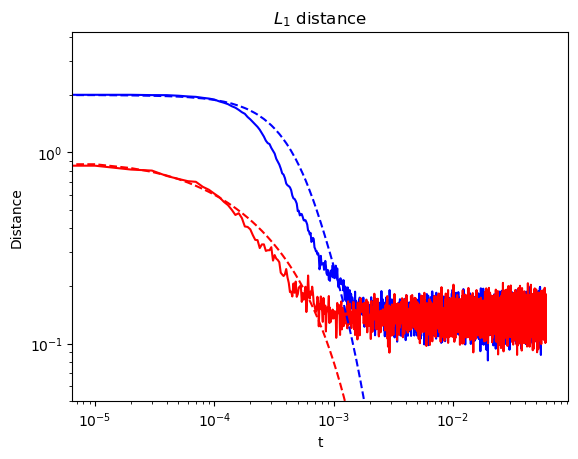

In [11]:
ensemble.plot_distances(distance_function=mpemba.distance_functions.L1)
equilibrium_boltzmann = np.repeat(ensemble.potential.boltzmann(bins, 1)[np.newaxis,:, np.newaxis], repeats = p_trajectories.shape[0], axis=0)
L1_boltzmann_distances = mpemba.distance_functions.L1(p_trajectories, equilibrium_boltzmann, dx=ensemble.dx, axis=1)
plt.loglog(ensemble.times, L1_boltzmann_distances[1,:], 'b--')
plt.loglog(ensemble.times, L1_boltzmann_distances[0,:], 'r--')
plt.title(r"$L_1$ distance")
plt.ylim(5e-2)

In [ ]:
# fpe_L1_df = pd.DataFrame(L1_distances.T, columns=['p_0', 'p_1'], index=ensemble.times)
# fpe_L1_df.index.name='t'
# fpe_L1_df.to_csv("symmetrisation_L1_FPE.csv")

In [ ]:
# boltzmann_distance_df = pd.DataFrame(ensemble.get_distances().T, columns=['p_0', 'p_1'], index=ensemble.times)
# boltzmann_distance_df.index.name='t'
# boltzmann_distance_df.to_csv("symmetrisation_distances_boltzmann.csv")

In [ ]:
# boltzmann_L1_df = pd.DataFrame(L1_boltzmann_distances.T, columns=['p_0', 'p_1'], index=ensemble.times)
# boltzmann_L1_df.index.name='t'
# boltzmann_L1_df.to_csv("symmetrisation_L1_boltzmann_FPE.csv")

Text(0.5, 1.0, 'KL distance')

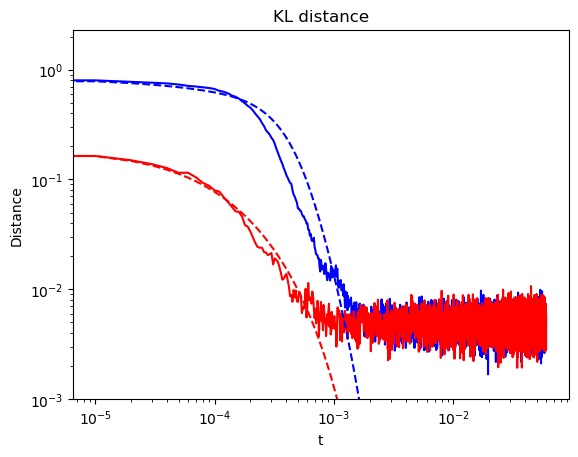

In [ ]:
ensemble.plot_distances(distance_function=mpemba.distance_functions.kullback_leibler)
KL_boltzmann_distances = mpemba.distance_functions.kullback_leibler(p_trajectories, equilibrium_boltzmann, dx=ensemble.dx, axis=1)
plt.loglog(ensemble.times, KL_boltzmann_distances[1,:], 'b--')
plt.loglog(ensemble.times, KL_boltzmann_distances[0,:], 'r--')
plt.ylim(1e-3)
plt.title("KL distance")

(0.0, 0.003)

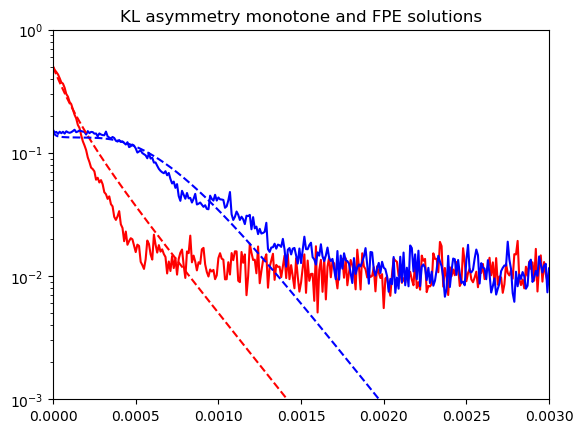

In [61]:
distance_data = ensemble.get_distances(distance_function=KL_asymmetry_monotone)
times = np.arange(0,p_trajectories.shape[2]*1e-5, 1e-5)

plt.semilogy(times, distance_data[0,:], color='r')
plt.semilogy(times, distance_data[1,:], color='b')
plt.semilogy(times, KL_distances[0,:], '--', color='r')
plt.semilogy(times, KL_distances[1,:], '--', color='b')
plt.title("KL asymmetry monotone and FPE solutions")
plt.ylim((0.001, 1))
plt.xlim(0, 0.003)

(0.0, 0.003)

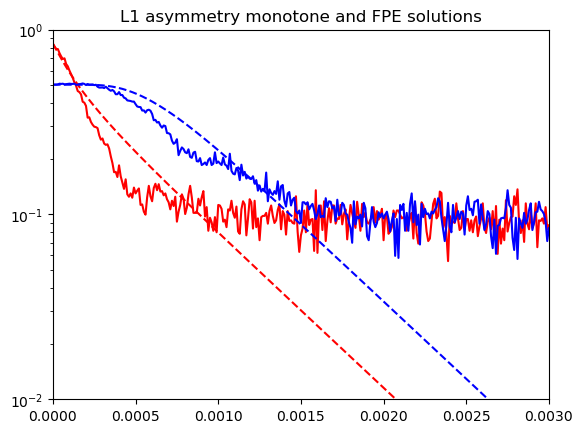

In [112]:
L1_distance_data = ensemble.get_distances(distance_function=L1_asymmetry_monotone)
times = np.arange(0,p_trajectories.shape[2]*1e-5, 1e-5)

plt.semilogy(times, L1_distance_data[0,:], color='r')
plt.semilogy(times, L1_distance_data[1,:], color='b')
plt.semilogy(times, L1_distances[0,:], '--', color='r')
plt.semilogy(times, L1_distances[1,:], '--', color='b')
plt.title("L1 asymmetry monotone and FPE solutions")
plt.ylim((0.01, 1))
plt.xlim(0, 0.003)

In [ ]:
L1_distances = ensemble.get_distances(regenerate=True, symmetric_domain=True, distance_function=L1_asymmetry_monotone)
KL_distances = ensemble.get_distances(regenerate=True, symmetric_domain=True, distance_function=KL_asymmetry_monotone)

df = pd.DataFrame(np.array([*L1_distances, *KL_distances]).T, columns = ['L1_0', 'L1_1', 'KL_0', 'KL_1'], index=ensemble.times)
df.index.name = 't'
df
# df.to_csv(directory+filename+"_distances.csv")

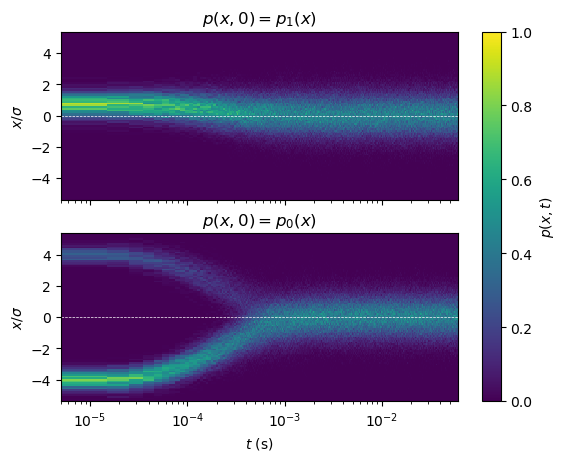

In [7]:
plt.close()

# Density plot of time evolution
fig, ax = plt.subplots(2, sharex=True)
for i in range(2):
    pcm = ax[i].pcolormesh(ensemble.times[1:], bins, np.copy(heights[i,:,1:]), vmin=0, vmax=1, shading='auto')
    ax[i].set_ylabel(r'$x/\sigma$')
    ax[i].set_xscale('log')
    ax[i].axhline(0, color='w', linestyle='--', linewidth=0.5)

cbar = fig.colorbar(pcm, ax=ax, orientation='vertical')
cbar.set_label(r'$p(x,t)$') 
ax[0].set_title(r"$p(x,0)=p_1(x)$")
ax[1].set_title(r"$p(x,0)=p_0(x)$")
plt.xlabel(r"$t$ (s)")
# plt.savefig("pdf_evolution.pdf")
plt.show()

In [31]:
ensemble.expt_length

0.060000000000000005

In [44]:
samples = 500

exponential_selection_func = lambda x, x_0: (ensemble.expt_length/ensemble.dt)*(np.exp(x/x_0)-1)/(np.exp(samples/x_0)-1)
selected_heights = np.rint(exponential_selection_func(np.arange(0,samples, 1), 150)).astype('int')[1:]

t_s = ensemble.times[selected_heights]
p_A = heights[0,:,selected_heights]
p_B = heights[1,:,selected_heights]
selected_heights

array([   1,    3,    4,    6,    8,    9,   11,   12,   14,   15,   17,
         18,   20,   22,   23,   25,   27,   28,   30,   32,   33,   35,
         37,   39,   40,   42,   44,   46,   47,   49,   51,   53,   55,
         56,   58,   60,   62,   64,   66,   68,   70,   72,   74,   76,
         78,   80,   82,   84,   86,   88,   90,   92,   94,   96,   98,
        100,  103,  105,  107,  109,  111,  114,  116,  118,  120,  123,
        125,  127,  130,  132,  134,  137,  139,  142,  144,  146,  149,
        151,  154,  156,  159,  161,  164,  167,  169,  172,  174,  177,
        180,  182,  185,  188,  191,  193,  196,  199,  202,  205,  207,
        210,  213,  216,  219,  222,  225,  228,  231,  234,  237,  240,
        243,  246,  250,  253,  256,  259,  262,  265,  269,  272,  275,
        279,  282,  285,  289,  292,  296,  299,  303,  306,  310,  313,
        317,  320,  324,  328,  331,  335,  339,  342,  346,  350,  354,
        358,  362,  366,  369,  373,  377,  381,  3

In [48]:
selected_heights.shape

(499,)

In [46]:
h0 = pd.DataFrame(p_A, index=t_s, columns=bins).stack().reset_index().rename(columns={'level_0':'t', 'level_1':'x', 0: 'h0'})
h1 = pd.DataFrame(p_B, index=t_s, columns=bins).stack().reset_index().rename(columns={'level_0':'t', 'level_1':'x', 0: 'h1'})
df_h = pd.merge(h0, h1, on=['t', 'x'])

In [47]:
df_h
df_h.to_csv("histogram_time_evolution_downsampled.csv")

In [ ]:
smooth_domain = np.linspace(bins.min(), bins.max(), 100_000)
p_0_generator = scipy.interpolate.interp1d(bins, p_0)
p_1_generator = scipy.interpolate.interp1d(bins, p_1)

p_0_interpolated = p_0_generator(smooth_domain)
p_1_interpolated = p_1_generator(smooth_domain)

100%|██████████| 5999/5999 [00:00<00:00, 15746.20it/s]


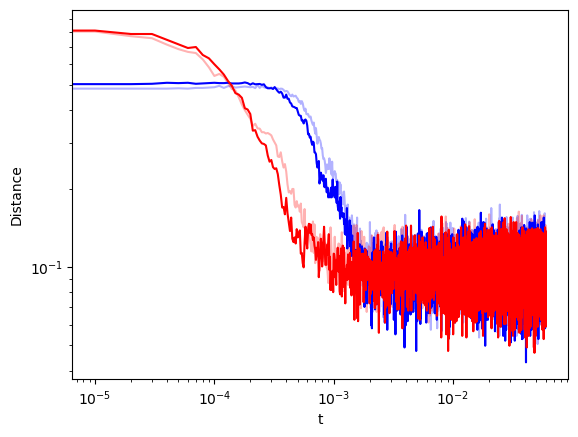

In [13]:
simulated_data = mpemba.simulation_methods.run_asymmetry_mpemba_simulations(np.array([p_0_interpolated/p_0_interpolated.sum(), p_1_interpolated/p_1_interpolated.sum()]), num_particles=ensemble.N, potential=potential, num_allowed_initial_positions=len(p_0_interpolated), expt_length=ensemble.expt_length, gamma=gamma)
simulated_ensemble = mpemba.Ensemble(simulated_data, potential)
# simulated_ensemble.get_histograms(symmetric_domain=False)
simulated_ensemble.plot_distances(distance_function=L1_asymmetry_monotone, symmetric_domain=True, other_plt_kwargs={'alpha':0.3})
ensemble.plot_distances(distance_function=L1_asymmetry_monotone, regenerate=True, symmetric_domain=True)

0.09504752621050332


c:\Users\siddh\Desktop\Graduate files\Research\Symmetrisation Mpemba\2025_05_12\distance_functions.py:121: RuntimeWarning: divide by zero encountered in log
  log_ratio = np.where(np.isfinite(np.log(pdf_1)-np.log(pdf_2)), np.log(pdf_1)-np.log(pdf_2), epsilon*np.ones_like(pdf_1))
c:\Users\siddh\Desktop\Graduate files\Research\Symmetrisation Mpemba\2025_05_12\distance_functions.py:121: RuntimeWarning: invalid value encountered in subtract
  log_ratio = np.where(np.isfinite(np.log(pdf_1)-np.log(pdf_2)), np.log(pdf_1)-np.log(pdf_2), epsilon*np.ones_like(pdf_1))


0.09303754557730105


c:\Users\siddh\Desktop\Graduate files\Research\Symmetrisation Mpemba\2025_05_12\distance_functions.py:121: RuntimeWarning: divide by zero encountered in log
  log_ratio = np.where(np.isfinite(np.log(pdf_1)-np.log(pdf_2)), np.log(pdf_1)-np.log(pdf_2), epsilon*np.ones_like(pdf_1))
c:\Users\siddh\Desktop\Graduate files\Research\Symmetrisation Mpemba\2025_05_12\distance_functions.py:121: RuntimeWarning: invalid value encountered in subtract
  log_ratio = np.where(np.isfinite(np.log(pdf_1)-np.log(pdf_2)), np.log(pdf_1)-np.log(pdf_2), epsilon*np.ones_like(pdf_1))


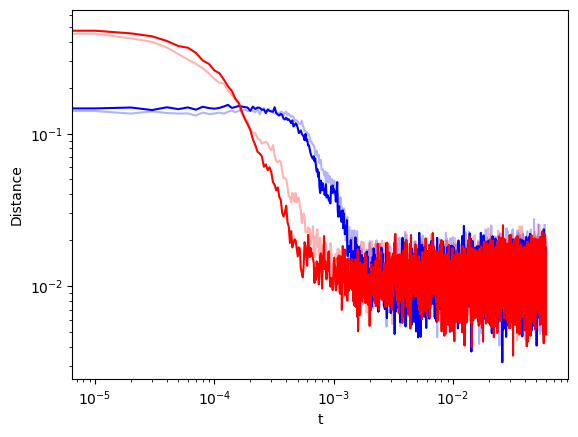

In [14]:
simulated_ensemble.plot_distances(distance_function=KL_asymmetry_monotone, symmetric_domain=True, other_plt_kwargs={'alpha':0.3})
ensemble.plot_distances(distance_function=KL_asymmetry_monotone, regenerate=True, symmetric_domain=True)

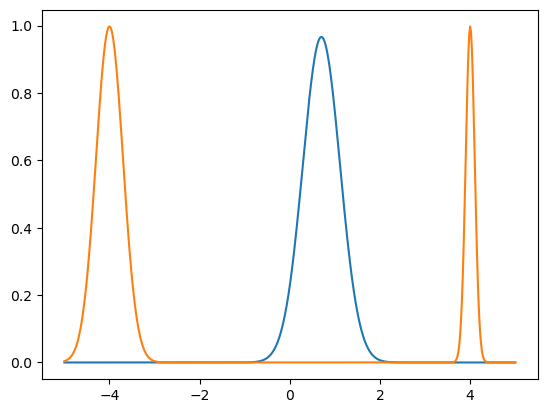

In [67]:
gaussian = lambda x, mu, sigma: np.exp(-(x-mu)**2/(2*sigma**2))
x = np.linspace(-5, 5, 500)
dx = x[1]-x[0]
p_A = gaussian(x, 0.8, 0.4)+gaussian(x, 0.6, 0.4)
p_B = gaussian(x, 4, 0.1)+gaussian(x, -4, 0.3)
p_A, p_B = p_A/(p_A.sum()*dx), p_B/(p_B.sum()*dx)

plt.plot(x, p_A)
plt.plot(x, p_B)


In [12]:
p_A.shape

(500,)

[0.20427978] [0.21948769]


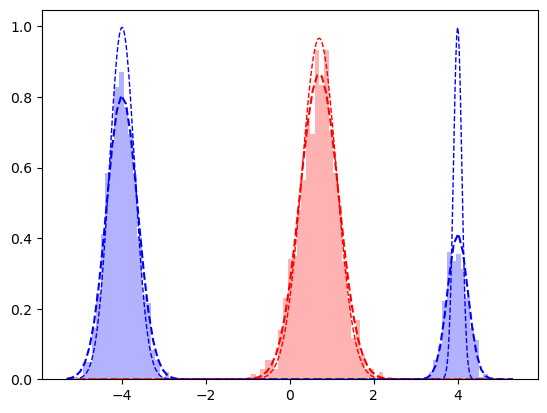

In [69]:
noisy_pdf = lambda x, sigma: gaussian(x, 0, sigma)/gaussian(x, 0, sigma).sum()

p_A_coarse = gaussian(gutcheck_bins, 0.8, 0.4)+gaussian(gutcheck_bins, 0.6, 0.4)
p_B_coarse = gaussian(gutcheck_bins, 4, 0.1)+gaussian(gutcheck_bins, -4, 0.3)
p_A_coarse /= p_A_coarse.sum()*ensemble.dx
p_B_coarse /= p_B_coarse.sum()*ensemble.dx

p_A_noisy = lambda x, sigma: np.convolve(p_A_coarse, noisy_pdf(x, sigma), mode='same')/(np.convolve(p_A_coarse, noisy_pdf(x, sigma), mode='same').sum()*ensemble.dx)
p_B_noisy = lambda x, sigma: np.convolve(p_B_coarse, noisy_pdf(x, sigma), mode='same')/(np.convolve(p_B_coarse, noisy_pdf(x, sigma), mode='same').sum()*ensemble.dx)

# p_A_noisy, p_B_noisy = p_A_noisy/(p_A_noisy.sum()*dx), p_B_noisy/(p_B_noisy.sum()*dx) # Renormalise
plt.bar(gutcheck_bins, gutcheck_heights[0][0,:], width=ensemble.dx, color='r', label=r'$p_0(x)$', alpha=0.3)
plt.bar(gutcheck_bins, gutcheck_heights[0][1,:], width=ensemble.dx, color='b', label=r'$p_1(x)$', alpha=0.3)
sigma_A_opt, _ = scipy.optimize.curve_fit(p_A_noisy, xdata=gutcheck_bins, ydata=gutcheck_heights[0][0,:], p0=[0.2])
sigma_B_opt, _ = scipy.optimize.curve_fit(p_B_noisy, xdata=gutcheck_bins, ydata=gutcheck_heights[0][1,:], p0=[0.2])
print(sigma_A_opt, sigma_B_opt)
plt.plot(gutcheck_bins, p_A_noisy(gutcheck_bins, *sigma_A_opt), color='red', linestyle='--')
plt.plot(gutcheck_bins, p_B_noisy(gutcheck_bins, *sigma_B_opt), color='blue', linestyle='--')
plt.plot(x, p_A, color='red', linestyle='--', lw=1)
plt.plot(x, p_B, color='blue', linestyle='--', lw=1)
# print(sigma_A_opt, sigma_B_opt)

[0.33963028] [0.32319875]


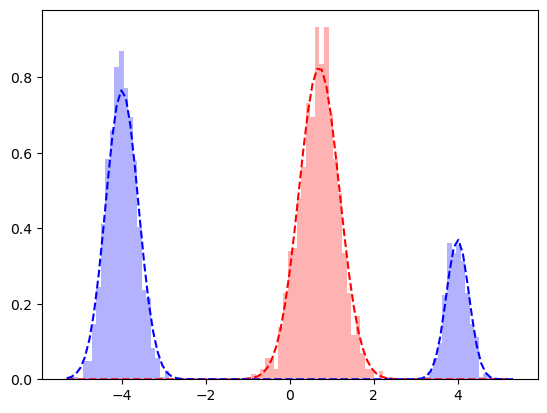

In [85]:
2*D*1e-5 #+ 3*0.25**2

# plt.bar(bins, heights[0,:,0], width=ensemble.dx, color='r', label=r'$p_0(x)$', alpha=0.3)
# plt.bar(bins, heights[1,:,0], width=ensemble.dx, color='b', label=r'$p_1(x)$', alpha=0.3)

sigma_A_opt, _ = scipy.optimize.curve_fit(p_A_noisy, xdata=gutcheck_bins, ydata=heights[0,:,2], p0=[0.2])
sigma_B_opt, _ = scipy.optimize.curve_fit(p_B_noisy, xdata=gutcheck_bins, ydata=heights[1,:,2], p0=[0.2])
print(sigma_A_opt, sigma_B_opt)

plt.bar(bins, heights[0,:,0], width=ensemble.dx, color='r', label=r'$p_0(x)$', alpha=0.3)
plt.bar(bins, heights[1,:,0], width=ensemble.dx, color='b', label=r'$p_1(x)$', alpha=0.3)
plt.plot(gutcheck_bins, p_A_noisy(gutcheck_bins, 0.25), color='red', linestyle='--')
plt.plot(gutcheck_bins, p_B_noisy(gutcheck_bins, 0.25), color='blue', linestyle='--')

[0.         0.67024327]


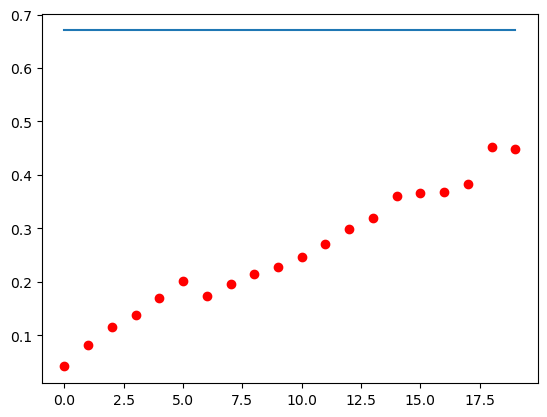

In [111]:
sigma_A_vals, sigma_B_vals = [], []

t = 20
for i in range(t):
    sigma_A_opt, _ = scipy.optimize.curve_fit(p_A_noisy, xdata=gutcheck_bins, ydata=heights[0,:,i], p0=[0.2])
    sigma_B_opt, _ = scipy.optimize.curve_fit(p_B_noisy, xdata=gutcheck_bins, ydata=heights[1,:,i], p0=[0.2])
    sigma_A_vals.append(*sigma_A_opt**2)
    sigma_B_vals.append(*sigma_B_opt**2)
# print(sigma_A_vals, sigm)

popt, pcov = scipy.optimize.curve_fit(lambda x, m, b: m*x+b, xdata=np.arange(t), ydata=sigma_A_opt, p0=[(sigma_A_opt[-1]-sigma_A_opt[0])/t, sigma_A_opt[0]])
print(popt)
m, b = popt
plt.scatter(np.arange(t), sigma_A_vals, color='r')
plt.plot(np.arange(t), m*np.arange(t)*1e-5+b)
# plt.plot(np.arange(t)*1e-5, sigma_B_vals, 'b')
# plt.ylim((0,10))